<span style="font-size:10pt">DIADEM course "Deep Learning - Image Classification" / Mai 20-21, 2026<br> 
v1.0  - CC BY-SA 4.0 Jean-Luc CHARLES (Jean-Luc.charles@mailo.com)</span>

<div class="alert alert-block alert-danger">
<span style="color:brown;font-family:arial;font-size:normal">
     It is important to define a <span style="font-weight:bold;">Python Virtual Environment</span> (PVE) for each Python project:<br>
     a PVE makes it possible to control for each project the versions of the Python interpreter and “sensitive” modules (tensorflow...).<br> 
$\leadsto$ This notebook is run with the command `uv run jupyter lab` to ensure it uses the PVE of the projet.

<span style="font-family:arial;font-size:1cm;">
    Machine learning with tensorflow2/keras Python modules
</span>

# Training a simple Dense Neural Network to classify small images

## 0 - Preliminaries

### Configure KAGGLE environment if needed

In [1]:
import sys
from pathlib import Path

if 'kaggle' in Path.cwd().as_posix():
    KAGGLE = True
    print(f'Notebook running on KAGGLE')
else:
    KAGGLE = False
    print(f'Notebook not running on KAGGLE')


if KAGGLE:
    #
    # Add the path to the <utils> directory to the sys.path list:
    #
    paths = list(Path('/kaggle').rglob('utils'))
    if len(paths) == 0:
        print('\tNo <utils> directory found in your workspace, sorry.')
    else:
        util_path = paths[0].parent

        util_path = paths[0].parent.as_posix()
        sys.path.append(util_path)
        print(f'\t<{util_path}> added to sys.path.')

    #
    # Create a link <img> to the image directory of the dataset éDL img"
    #
    img_dataset_path = Path('/kaggle/input/datasets/jlcharles/dl-img')
    link_to_img_dir  = Path.cwd() / 'img'
    if not link_to_img_dir.is_symlink(): 
        link_to_img_dir.symlink_to(img_dataset_path)
    print(f'\tlink <{link_to_img_dir}> to <{img_dataset_path}> OK')

Notebook not running on KAGGLE


#### On KAGGLE platform we must install the GPUtil module:

In [2]:
! test $(pwd) = '/kaggle/working' && pip install GPUtil

### Import the Python modules

In [3]:
# suppress tensorflow verbose warnings
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

In [4]:
# Deep Learning modules:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# General modules:
import numpy as np
import matplotlib.pyplot as plt
from time import time
from pathlib import Path
from cpuinfo import get_cpu_info
import GPUtil
import sys
import random
import cv2

# Custom modules:
from utils.tools import scan_dir, plot_images, plot_loss_accuracy, elapsed_time_since, show_conf_matrix, plot_proportion_bar

I0000 00:00:1774879598.360042  240312 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774879598.360549  240312 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1774879599.184284  240312 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774879599.184535  240312 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [5]:
print(f"Python    : {sys.version.split()[0]}")
print(f"tensorflow: {tf.__version__} with keras {keras.__version__}")
print(f"numpy     : {np.__version__}")
print(f"OpenCV    : {cv2.__version__}")

Python    : 3.13.12
tensorflow: 2.21.0 with keras 3.13.2
numpy     : 2.4.4
OpenCV    : 4.13.0


In [6]:
# allows to visualize the graphs directly in the cell of the N.B.
%matplotlib inline

# SEED will be used to fix the _seed_ of the random generators to have continuations
# of repeatable random numbers
SEED = 1234

tf.get_logger().setLevel('ERROR')

#### Check wether GPU is available or not:

In [7]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"Found {len(gpus)} GPU(s):")
    for gpu in gpus:
        print(f"  - {gpu.name}")
else:
    print("No GPU found. Using CPU.")

No GPU found. Using CPU.


In [8]:
Path.cwd()

PosixPath('/home/jlc/work/IA-MachineLearning/18-DIADEM/Notebooks')

### Create the `models` directory

In [9]:
if Path.cwd().name != 'Notebooks':
    print("You should save & close this notebook and type 'uv run jupyter lab'")
    print("from the <Notebooks> directory")
else:
    print(f'{"WORKING DIRECTORY":20s}: {Path.cwd()}')
    model_path = Path("./models")
    model_path.mkdir(exist_ok=True)
    print(f'{"MODELS DIRECTORY":20s}: {model_path.absolute().as_posix()}')

WORKING DIRECTORY   : /home/jlc/work/IA-MachineLearning/18-DIADEM/Notebooks
MODELS DIRECTORY    : /home/jlc/work/IA-MachineLearning/18-DIADEM/Notebooks/models


## 1 - Prepare the MNIST dataset (images and labels)

#### Loading of the data

We use the keras `load_data` function to load the data from the MNIST 
(see [tf.keras.datasets.mnist.load_data](https://www.tensorflow.org/api_docs/python/tf/keras/datasets/mnist/load_data)):<br>
- `train_img`, `train_lab` are the training images and labels,
- `valid_img`, `valid_lab` are the validation images and labels.

In [10]:
(train_img, train_lab), (valid_img, valid_lab) = keras.datasets.mnist.load_data()

Let's check the `shape` and `dtype` attributes of the numpy arrays:

In [11]:
print(f"train_img.shape:  {train_img.shape}, dtype: {train_img.dtype}")
print(f"valid_img.shape:  {valid_img.shape}, dtype: {valid_img.dtype}")
print(f"train_lab.shape: {train_lab.shape}, dtype: {train_lab.dtype}")
print(f"lab_vaild.shape: {valid_lab.shape}, dtype: {valid_lab.dtype}")

train_img.shape:  (60000, 28, 28), dtype: uint8
valid_img.shape:  (10000, 28, 28), dtype: uint8
train_lab.shape: (60000,), dtype: uint8
lab_vaild.shape: (10000,), dtype: uint8


### Visualization of images and labels:

The local module `utils.tools` defines the `plot_images` function which can be used to display a grid of MNIST images.<br>
Let's plot a grid of images 3 x 10 beginning with the 600th image:

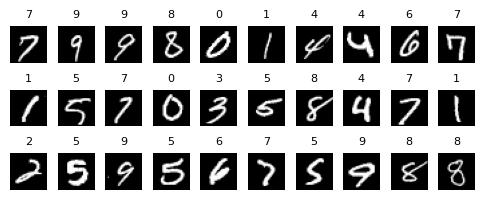

In [12]:
plot_images(train_img, 3, 10, 599, label_array=train_lab)

### Create the 3 datasets: train, validation & test

To follow the _state of the art_, we will split the dataset into train, validation & test datasets.<br>
A simple way to do this is to keep the train dataset and to split the current validation dataset in two equal subsets:
- a new smaller validation subset,
- a new test subset.

In [13]:
# note on train_test_split : Stratified train/test split is not implemented for shuffle=False 
# We give the seed value with the 'random_state' parameter to ensure a reproducible splitting.

valid_img, test_img, valid_lab, test_lab = train_test_split(valid_img, valid_lab,
                                                            stratify=valid_lab,
                                                            test_size=0.5,
                                                            shuffle=True,
                                                            random_state=SEED)

Let's check the sizes of the 3 datasets:

In [14]:
print(f'train:  {train_img.shape}')
print(f'valid:  {valid_img.shape}')
print(f'test :  {test_img.shape}')

train:  (60000, 28, 28)
valid:  (5000, 28, 28)
test :  (5000, 28, 28)


We can verify that the proportion of digits remains homogenous in all the datasets:

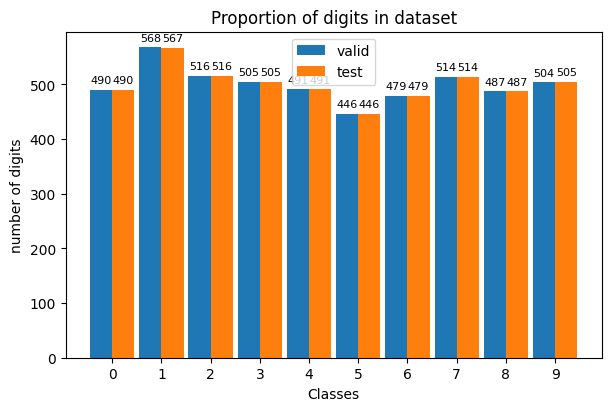

In [15]:
prop = {}
prop['valid'] = [ (valid_lab == i).sum() for i in range(10)]
prop['test']  = [ (test_lab  == i).sum() for i in range(10)]
plot_proportion_bar(prop, range(10))

### Define important parameters

To avoid hard-coding the number of training, valid and test images as well as the size of the images, these parameters are recovered from the data set:
- with the shape attribute of the `train_img` and `test_im` arrays
- with the size attribute of the first training image for example


In [16]:
NB_TRAIN_IMG = train_img.shape[0] # number of training images
NB_VALID_IMG = valid_img.shape[0] # number of validation images 
NB_TEST_IMG  = test_img.shape[0]  # number of test images

NB_PIXEL     = train_img[0].size  # number of elements (pixels) of the firts training image: 

# Display checking:
print(f"{NB_TRAIN_IMG} training images, {NB_VALID_IMG} validation images and {NB_TEST_IMG} test images")
print(f"{train_img.shape[1]}x{train_img.shape[2]}={NB_PIXEL} pixels in each image")

# number of classes:
NB_CLASS = len(set(train_lab))
print(f"{NB_CLASS} classes found in the `train_lab` ndarray")

60000 training images, 5000 validation images and 5000 test images
28x28=784 pixels in each image
10 classes found in the `train_lab` ndarray


### Check: display the shapes of the dataset arrays

In [17]:
print(f'train:  {train_img.shape}')
print(f'valid:  {valid_img.shape}')
print(f'test :  {test_img.shape}')

train:  (60000, 28, 28)
valid:  (5000, 28, 28)
test :  (5000, 28, 28)


## 3 - Process input data

Two treatments must be applied to the data from the MNIST database:
- on the images: transform the matrices of  28$\,\times\,$28 pixels (`uint8`integers) into **normalized** vectors $(V_i)_{i=0..783}$ of 784 real values $V_i$ with $ 0 \leqslant V_i \leqslant 1$;
- on labels: transform scalar numbers into *one-hot* vectors.

### Transform input matrices into normalized vectors

We define the arrays `x_train`, `x_valid` and `x_test` containing the matrices of the arrays `train_img`, `valid_img` and `test_img` *flattened* as normalized vectors (values between 0 and 1):

In [18]:
x_train = train_img.reshape(NB_TRAIN_IMG, NB_PIXEL)/255
x_valid = valid_img.reshape(NB_VALID_IMG, NB_PIXEL)/255
x_test  = test_img.reshape(NB_TEST_IMG, NB_PIXEL)/255

#check:
print(f'train: {x_train.shape}, min: {x_train.min()}, max: {x_train.max()}')
print(f'valid: {x_valid.shape}, min: {x_valid.min()}, max: {x_valid.max()}')
print(f'test : {x_test.shape}, min: {x_test.min()}, max: {x_test.max()}')

train: (60000, 784), min: 0.0, max: 1.0
valid: (5000, 784), min: 0.0, max: 1.0
test : (5000, 784), min: 0.0, max: 1.0


### *one-hot* encoding of labels:

We use the **keras** `to_categorical` function (see [tf.keras.utils.to_categorical](https://www.tensorflow.org/api_docs/python/tf/keras/utils/to_categorical)) to define the `y_train` and `y_valid` arrays containing the *hot-one* encoded version of `lab_train` and `lab_valid`:

In [19]:
from tensorflow.keras.utils import to_categorical
# 'one-hot' encoding' of labels :
y_train = to_categorical(train_lab)
y_valid = to_categorical(valid_lab)
y_test  = to_categorical(test_lab)

Let's check the first 10 values of the `lab_train` and `y_train` arrays:

In [20]:
print(train_lab[:10])
print(y_train[:10])

[5 0 4 1 9 2 1 3 1 4]
[[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]]


## 4 - Build the Dense Neural Network (DNN)

 To get short computation times we build a simple dense network to classify the MNIST images.<br>
 Of course, this is not the "state of the art" : convolutive NN, transformers have much more impressive scores, but we just want want short training computation time.<br><br>
We buildthis naive **dense network**:
- an **input layer** of 784 values (the pixels of the MNIST 28 $\times$ 28 images flattened in the form of a vector of 784 normalized `float` numbers),
- a **hidden layer** of 784 neurons using the `relu` activation function,
- an **output layer** of 10 neurons, for the classification of the 10 digits {0,1,2...9}, using the `softmax` activation function adapted to classification problems .

<p style="text-align:center; font-style:italic; font-size:12px;">
      <img src="img/Simple-DNN.png" alt="Simple-DNN.png" style="width:900px;"><br>
     [image credit: JLC]

In [21]:
NB_INPUT  = NB_PIXEL
NB_NEURON = NB_PIXEL

For the sake of convenience we défine a function to build the NN: 

In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

def build_DNN(seed=None):

    if seed is not None:
        ##########################
        # Deterministic training #
        ##########################
        # 1/ set the seed of the random generators involved by tensorflow:
        tf.keras.utils.set_random_seed(seed)
        # 2/ make the tf ops determinisctic 
        # [see https://blog.tensorflow.org/2022/05/whats-new-in-tensorflow-29.html]
        tf.config.experimental.enable_op_determinism() 

    model = Sequential()
    model.add(Input(shape=(NB_INPUT,), name='input'))             # INPUT layer
    model.add(Dense(NB_NEURON, activation='relu', name='c1'))     # First hidden layer
    model.add(Dense(NB_CLASS, activation='softmax', name='c2'))   # OUTPUT layer
    model.compile(loss='categorical_crossentropy', optimizer='adam',  metrics=['accuracy'])
    return model

Lets's look at the number of _parameters_ (the _weights_) of the model:

In [23]:
model = build_DNN()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ c1 (Dense)                      │ (None, 784)            │       615,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ c2 (Dense)                      │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 623,290 (2.38 MB)

 Trainable params: 623,290 (2.38 MB)

 Non-trainable params: 0 (0.00 B)

## 5 - Elementary tests of the reproducibility of the DNN training...

Perfect reproducibility of a neural network training may be difficult to achieve with tensorflow...<br>
To highlight the question of reproducibility we run a short experiment: <br>
$\leadsto$ run a loop where the model is built without setting the seed, trained and evaluated once (_epochs=1_) at each iteration.

#### A/ Build the model at each lop lap without SEED: training not reproducible

In [24]:
print(get_cpu_info()['brand_raw'])
for _ in range(5):
    model = build_DNN()  # Build a new model without setting seed
    hist = model.fit(x_train, y_train, epochs=1, batch_size=32, validation_data=(x_valid, y_valid), verbose=2)    

11th Gen Intel(R) Core(TM) i7-1165G7 @ 2.80GHz
1875/1875 - 6s - 3ms/step - accuracy: 0.9436 - loss: 0.1896 - val_accuracy: 0.9688 - val_loss: 0.1032
1875/1875 - 6s - 3ms/step - accuracy: 0.9436 - loss: 0.1898 - val_accuracy: 0.9716 - val_loss: 0.0961
1875/1875 - 6s - 3ms/step - accuracy: 0.9421 - loss: 0.1916 - val_accuracy: 0.9678 - val_loss: 0.1054
1875/1875 - 7s - 3ms/step - accuracy: 0.9438 - loss: 0.1903 - val_accuracy: 0.9668 - val_loss: 0.1025
1875/1875 - 7s - 4ms/step - accuracy: 0.9427 - loss: 0.1901 - val_accuracy: 0.9676 - val_loss: 0.1071


If we repeat 5 times the first epoch of the training, the `val_accuracy`and `val_loss` differ at each iteration $\leadsto$ the training is not reproducible.

#### B/ Reload a initial model weights without setting SEED: training not reproducible

We save the weights of a model built without setting the seed:

In [25]:
model = build_DNN()
model.save_weights('models/DNN_noseed.weights.h5')

In [26]:
print(get_cpu_info()['brand_raw'])
model = build_DNN()
for _ in range(5):
    model.load_weights('models/DNN_noseed.weights.h5') # reload the inital model weights
    hist = model.fit(x_train, y_train, epochs=1, batch_size=32, validation_data=(x_valid, y_valid), verbose=2)    

11th Gen Intel(R) Core(TM) i7-1165G7 @ 2.80GHz
1875/1875 - 7s - 4ms/step - accuracy: 0.9428 - loss: 0.1899 - val_accuracy: 0.9676 - val_loss: 0.1060


/home/jlc/work/IA-MachineLearning/18-DIADEM/Notebooks/.venv/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 10 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


1875/1875 - 6s - 3ms/step - accuracy: 0.9483 - loss: 0.1726 - val_accuracy: 0.9682 - val_loss: 0.1019
1875/1875 - 6s - 3ms/step - accuracy: 0.9494 - loss: 0.1715 - val_accuracy: 0.9720 - val_loss: 0.0899
1875/1875 - 6s - 3ms/step - accuracy: 0.9481 - loss: 0.1713 - val_accuracy: 0.9756 - val_loss: 0.0836
1875/1875 - 6s - 3ms/step - accuracy: 0.9485 - loss: 0.1724 - val_accuracy: 0.9738 - val_loss: 0.0862


The `val_loss` is still non-reproducible.

#### C/ Build the model with SEED at each lop lap: training perfectly reproducible

In [27]:
print(get_cpu_info()['brand_raw'])
for _ in range(5):
    model = build_DNN(seed=1234)  # Build a new model with seed set
    hist = model.fit(x_train, y_train, epochs=1, batch_size=32, validation_data=(x_valid, y_valid), verbose=2)    

11th Gen Intel(R) Core(TM) i7-1165G7 @ 2.80GHz
1875/1875 - 6s - 3ms/step - accuracy: 0.9435 - loss: 0.1895 - val_accuracy: 0.9654 - val_loss: 0.1180
1875/1875 - 7s - 4ms/step - accuracy: 0.9435 - loss: 0.1895 - val_accuracy: 0.9654 - val_loss: 0.1180
1875/1875 - 7s - 4ms/step - accuracy: 0.9435 - loss: 0.1895 - val_accuracy: 0.9654 - val_loss: 0.1180
1875/1875 - 7s - 3ms/step - accuracy: 0.9435 - loss: 0.1895 - val_accuracy: 0.9654 - val_loss: 0.1180
1875/1875 - 7s - 4ms/step - accuracy: 0.9435 - loss: 0.1895 - val_accuracy: 0.9654 - val_loss: 0.1180


If we set the seed when creating the model at each iteration the `val_accuracy`and `val_loss` are perfectly reproducible &#128526;.

#### D/ Build the model with SEED  and load the model's structure & initial at each loop lap: training perfectly reproducible

In [28]:
model = build_DNN(seed=1234)
model.save('models/DNN_seed1234.keras')

In [29]:
print(get_cpu_info()['brand_raw'])
for _ in range(5):
    model = tf.keras.models.load_model('models/DNN_seed1234.keras') # reload the model structure & weights 
    hist = model.fit(x_train, y_train, epochs=1, batch_size=32, validation_data=(x_valid, y_valid), verbose=2)    

11th Gen Intel(R) Core(TM) i7-1165G7 @ 2.80GHz
1875/1875 - 6s - 3ms/step - accuracy: 0.9435 - loss: 0.1895 - val_accuracy: 0.9654 - val_loss: 0.1180
1875/1875 - 6s - 3ms/step - accuracy: 0.9435 - loss: 0.1895 - val_accuracy: 0.9654 - val_loss: 0.1180
1875/1875 - 6s - 3ms/step - accuracy: 0.9435 - loss: 0.1895 - val_accuracy: 0.9654 - val_loss: 0.1180
1875/1875 - 6s - 3ms/step - accuracy: 0.9435 - loss: 0.1895 - val_accuracy: 0.9654 - val_loss: 0.1180
1875/1875 - 6s - 3ms/step - accuracy: 0.9435 - loss: 0.1895 - val_accuracy: 0.9654 - val_loss: 0.1180


If we load the structure and the weights of the model at each iteration the `val_accuracy`and `val_loss` are perfectly reproducible  &#128526;.

<span style="color:brown">We can ensure the reproducibility of the first epoch of the training:<br>
$\leadsto$ by setting the seed at the model creation (and everywhere else where required)<br>
$\leadsto$ by reloading the entire network structure and weights with the __tf.keras.models.load_model__ function<br><br>
</spawn>

## 6 - Adressing the reproducibility of the DNN training...

### A - Run several trainings with a new model (no SEED) at each iteration $\leadsto$ not reproducible

To avoid long computation time, you can skip running the next cell and just look at the result obtained on a core-i7 standard laptop:

<p style="text-align:center; font-style:italic; font-size:12px;">
      <img src="img/range5_noSEED_epochs10_bs32.png" alt="range5_noSEED_epochs10_bs32.png" style="width:1024px;"><br>
     [image credit: JLC]

training #1
Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9432 - loss: 0.1905 - val_accuracy: 0.9630 - val_loss: 0.1217
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9769 - loss: 0.0747 - val_accuracy: 0.9748 - val_loss: 0.0854
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9866 - loss: 0.0444 - val_accuracy: 0.9758 - val_loss: 0.0878
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9916 - loss: 0.0275 - val_accuracy: 0.9780 - val_loss: 0.0827
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9932 - loss: 0.0213 - val_accuracy: 0.9742 - val_loss: 0.1022
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9939 - loss: 0.0180 - val_accuracy: 0.9834 - val_loss: 0.0767
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9947 - loss: 0.0154 - val_accuracy: 0.9828 - val_loss: 0.0819
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9950 - los

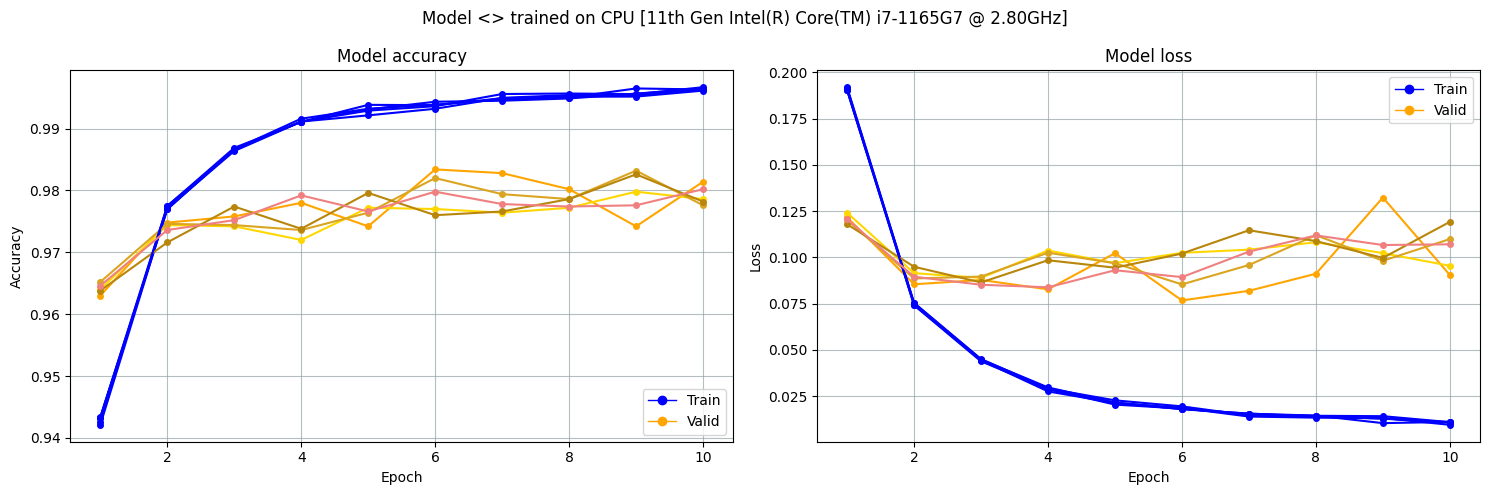

In [30]:
H, t0 = [], time()

for i in range(5):
    print(f"training #{i+1}")
    model = build_DNN()                # build a new network, no SEED given
    
    hist = model.fit(x_train, y_train, # images, labels
                     epochs=10,        # the total number of successive trainings
                     batch_size=32,    # split the whole dadaset in batches
                     validation_data=(x_valid, y_valid), 
                     verbose=1)
    H.append(hist)  

print(f' Total Train {elapsed_time_since(t0)}')   
plot_loss_accuracy(H)

The `val_loss` and `val_accuracy` differ at each of the training.<br>
It can be a problem if we train the model with a _callback_ like __early stoppping__ : the training will stop at a different epoch if we run the training many times.

### B - New model with SEED at each loop lap: $\leadsto$ reproducible

To avoid long computation time, you can skip running the next cell and just look at the result obtained on a core-i7 standard laptop:

<p style="text-align:center; font-style:italic; font-size:12px;">
      <img src="img/range5_SEED1234_epochs10_bs32.png" alt="range5_SEED1234_epochs10_bs32.png" style="width:1024px;"><br>
     [image credit: JLC]

training #1
Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9435 - loss: 0.1895 - val_accuracy: 0.9654 - val_loss: 0.1180
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9773 - loss: 0.0742 - val_accuracy: 0.9718 - val_loss: 0.0928
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9872 - loss: 0.0430 - val_accuracy: 0.9746 - val_loss: 0.0851
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9911 - loss: 0.0288 - val_accuracy: 0.9764 - val_loss: 0.0926
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9924 - loss: 0.0223 - val_accuracy: 0.9758 - val_loss: 0.0976
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9934 - loss: 0.0191 - val_accuracy: 0.9776 - val_loss: 0.0968
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9952 - loss: 0.0147 - val_accuracy: 0.9778 - val_loss: 0.1030
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9957 - los

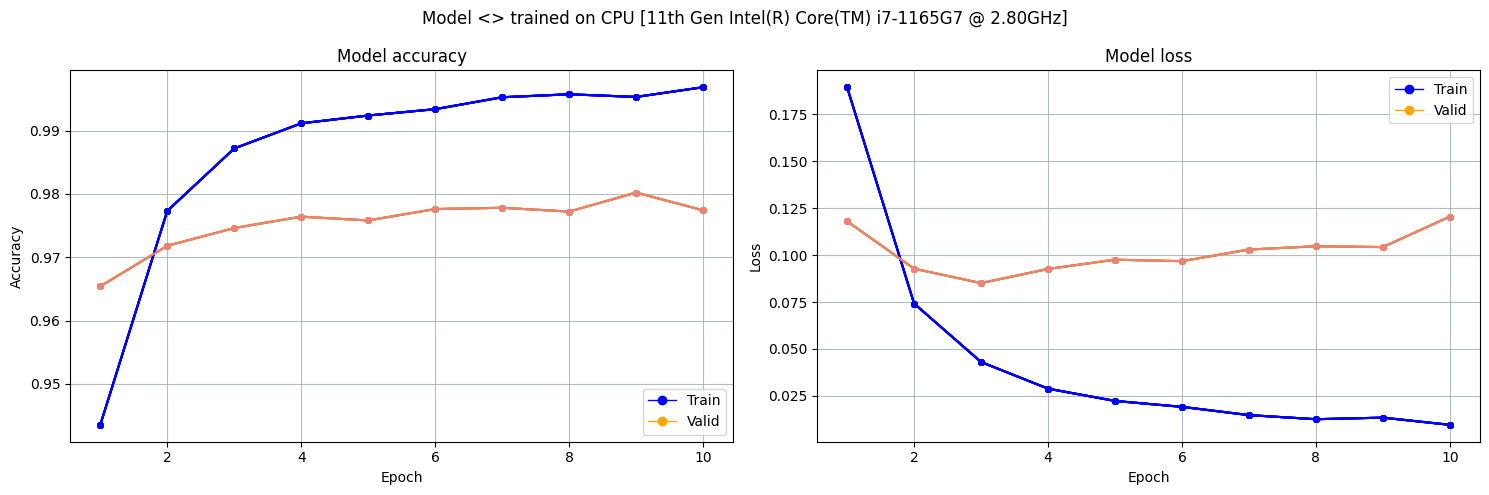

In [32]:
H, t0 = [], time()

for i in range(5):
    print(f"training #{i+1}")
    
    # build a new network/
    model = build_DNN(1234)            # build a new network with a fixed SEED
    
    hist = model.fit(x_train, y_train, # images, labels
                     epochs=10,        # the total number of successive trainings
                     batch_size=32,    # split of the whole dadaset in batches
                     validation_data=(x_valid, y_valid), 
                     verbose=1)
    H.append(hist)  

print(f' Total Train {elapsed_time_since(t0)}')
plot_loss_accuracy(H)

$\leadsto$ the repoducibility is perfect &#128526;

### C - Reloading the model structure & weights with SEED at each loop lap $\leadsto$ reproducible

To avoid long computation time, you can skip running the next cell and just look at the result obtained on a core-i7 standard laptop:

<p style="text-align:center; font-style:italic; font-size:12px;">
      <img src="img/range5_reload_SEED1234_epochs10_bs32.png" alt="range5_reload_SEED1234_epochs10_bs32.png" style="width:1024px;"><br>
     [image credit: JLC]

In [33]:
model = build_DNN(seed=1234)
model.save('models/DNN_seed1234.keras')

training #1
Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9435 - loss: 0.1895 - val_accuracy: 0.9654 - val_loss: 0.1180
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9773 - loss: 0.0742 - val_accuracy: 0.9718 - val_loss: 0.0928
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9872 - loss: 0.0430 - val_accuracy: 0.9746 - val_loss: 0.0851
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9911 - loss: 0.0288 - val_accuracy: 0.9764 - val_loss: 0.0926
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9924 - loss: 0.0223 - val_accuracy: 0.9758 - val_loss: 0.0976
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9934 - loss: 0.0191 - val_accuracy: 0.9776 - val_loss: 0.0968
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9952 - loss: 0.0147 - val_accuracy: 0.9778 - val_loss: 0.1030
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9957 - los

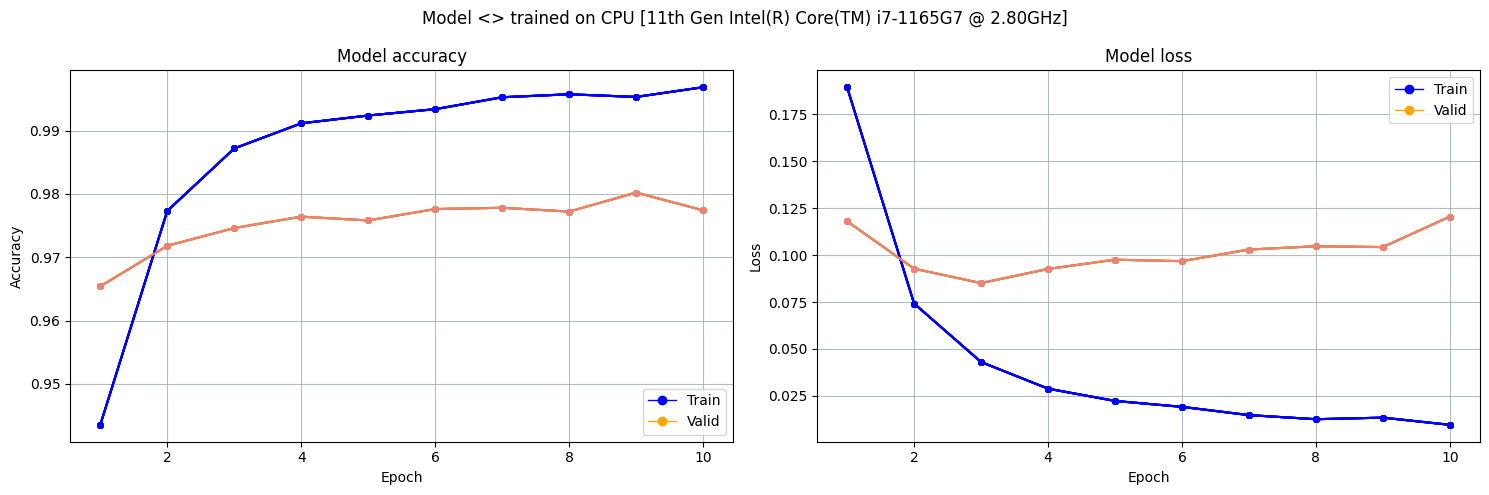

In [36]:
H, t0 = [], time()

for i in range(5):
    print(f"training #{i+1}")
                
    # reload the structure of the NN and its initial state 
    model = tf.keras.models.load_model('models/DNN_seed1234.keras') 
    
    # Deterministic tensorflow training: 
    tf.keras.utils.set_random_seed(1234) 
    tf.config.experimental.enable_op_determinism() 

    # train the network
    hist = model.fit(x_train, y_train, 
                     epochs=10, 
                     batch_size=32,
                     validation_data=(x_valid, y_valid), 
                     verbose=1)
    H.append(hist)  

print(f' Total Train {elapsed_time_since(t0)}')   
plot_loss_accuracy(H)

## 7 - Train the network

### Automatically stop training before over-fit
Keras offers tools to automatically stop learning by monitoring for example the growth of `val_accuracy` or the decrease of `val_loss` from one epoch to another (see the _EarlyStopping_ callback).

We can thus define a list of callback functions that we pass as an argument to the `fit` method with the agument named _callbacks_:

Epoch 1/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9435 - loss: 0.1895 - val_accuracy: 0.9654 - val_loss: 0.1180
Epoch 2/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9773 - loss: 0.0742 - val_accuracy: 0.9718 - val_loss: 0.0928
Epoch 3/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9872 - loss: 0.0430 - val_accuracy: 0.9746 - val_loss: 0.0851
Epoch 4/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9911 - loss: 0.0288 - val_accuracy: 0.9764 - val_loss: 0.0926
Epoch 5/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9924 - loss: 0.0223 - val_accuracy: 0.9758 - val_loss: 0.0976
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 3.


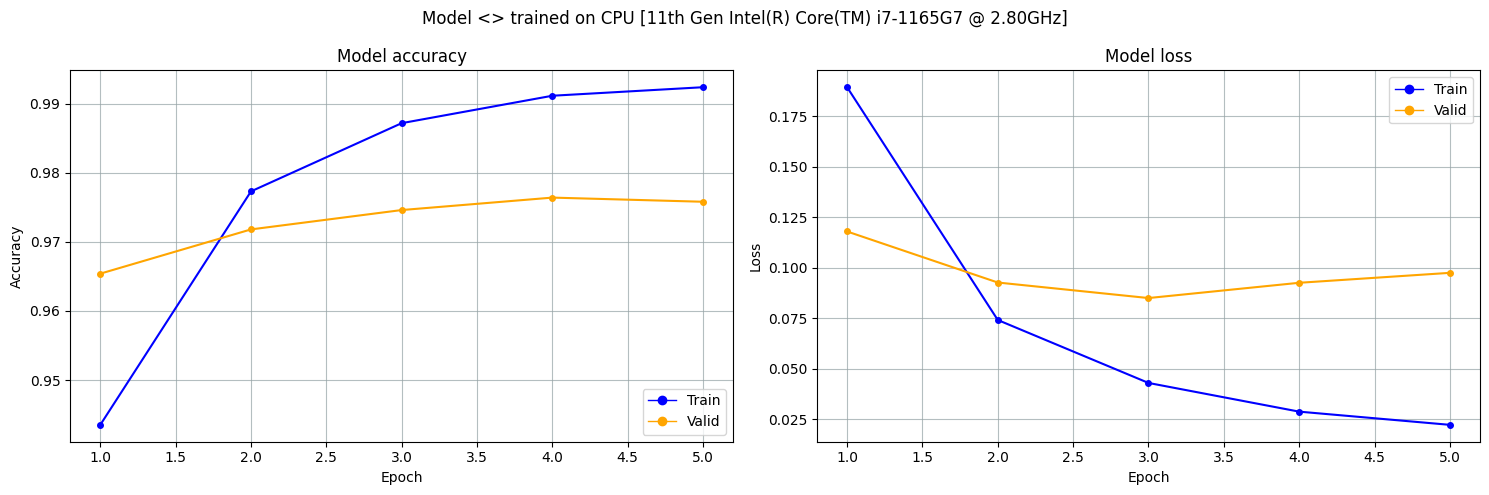

In [37]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# define the list of 'callback' fucntions:
callbacks_list = [
    EarlyStopping(monitor='val_loss',  # The parameter to monitor
                  patience=2,           # accept that 'val_accuracy' decrease 2 times
                  restore_best_weights=True,
                  verbose=1)
]

# load the network structure & initial weights:
model = tf.keras.models.load_model('models/DNN_seed1234.keras')

# Deterministic tensorflow training: 
tf.keras.utils.set_random_seed(1234)  # sets seeds for base-python, numpy and tf
tf.config.experimental.enable_op_determinism() 

hist = model.fit(x_train, y_train,
                 validation_data=(x_valid, y_valid), 
                 epochs=25,     # the total number of successive trainings
                 batch_size=32, # fragmentation of the whole dada set in batches
                 callbacks = callbacks_list)
plot_loss_accuracy(hist);

### Save the trained model

In [38]:
model.save('models/DNN_seed1234_trained.keras')

## 8 - Evaluate the trained network <a name="6"></a>

#### Load the structure and weights of a trained model:

In [39]:
model = tf.keras.models.load_model('models/DNN_seed1234_trained.keras')

#### Evaluate the predictions of the model:

In [40]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)

# Predicting labels for test images
predict_labels = np.argmax(model.predict(x_test), axis=-1)

# Display classification report
print("Classification Report:\n", classification_report(test_lab, predict_labels))

157/157 - 0s - 3ms/step - accuracy: 0.9768 - loss: 0.0743
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       490
           1       0.99      0.99      0.99       567
           2       0.99      0.97      0.98       516
           3       0.94      0.99      0.97       505
           4       0.97      0.97      0.97       491
           5       0.98      0.97      0.98       446
           6       1.00      0.97      0.98       479
           7       0.97      0.98      0.98       514
           8       0.98      0.97      0.98       487
           9       0.96      0.97      0.96       505

    accuracy                           0.98      5000
   macro avg       0.98      0.98      0.98      5000
weighted avg       0.98      0.98      0.98      5000



### Show the confusion matrix

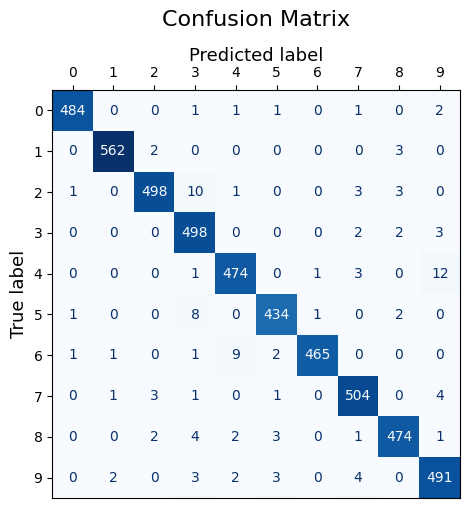

In [41]:
show_conf_matrix(test_lab, predict_labels, range(NB_CLASS), figsize=(7,6));